### Feature Engineering for Date Column

### Explain why these features might be useful for analysis.
### 1. Hour of the day: Useful for identifying diurnal patterns in weather (e.g., afternoon thunderstorms, morning fog)
### 2. Day of the week: Can reveal weekly patterns (e.g., weekend vs weekday weather patterns if related to human activity)
### 3. Month: Essential for capturing seasonal variations in precipitation and other weather phenomena


In [2]:
import pandas as pd
import numpy as np


# this will load our data set 
df = pd.read_csv('Weather_Records.csv')

In [3]:
df = pd.read_csv('Weather_Records.csv')

def fill_missing(df):  # function to fill_missing values
    df_filled = df.copy() # i created a copy of original dataset to not change the original 

    # for nuerical values in columns use forward and backward and then median

    numerical_columns = df.select_dtypes(include=[np.number]).columns

    for cols in numerical_columns:
        if df[cols].isnull().sum() > 0:
            # try forward fill
            df_filled[cols] = df_filled[cols].ffill()

            # now try backward fill
            df_filled[cols] = df_filled[cols].bfill()

            # check if still NaN we should use Median then 

            if df_filled[cols].isnull().sum() > 0:
                df_filled[cols].fillna(df_filled[cols].median() , inplace=True)

                #inplace=True means:

 #Modify the original DataFrame directly instead of creating a new copy.
    
    # Now for categorical columns we will use forward then backward then mode

    categorical_columns = df.select_dtypes(include=['object']).columns

    for cols in categorical_columns:
        if df[cols].isnull().sum() > 0:
            
            # forward fill we will use 
            df_filled[cols] = df_filled[cols].ffill()

            # Now try backward fill 
            df_filled[cols] = df_filled[cols].bfill()

            # if still NaN use we will mode
            if df_filled[cols].isnull().sum() > 0:
                # here i have used mode()[0] :means pick most frequent and then from the top [0] index
                df_filled[cols].fillna(df_filled[cols].mode()[0] if not df_filled[cols].mode().empty else 'unknown' , inplace = True)

    return df_filled





df_filled = fill_missing(df)


In [4]:
df_filled['StartTime(UTC)'] = pd.to_datetime(df_filled['StartTime(UTC)']) 

# create new time-based feature

df_filled['Hour'] = df_filled['StartTime(UTC)'].dt.hour   # make new column which is hour and extracted from StartTime(UTC) column
df_filled['DayOfWeek'] = df_filled['StartTime(UTC)'].dt.dayofweek # extrected the day 
df_filled['Month'] = df_filled['StartTime(UTC)'].dt.month # extracted month 


# Verify the new features
print("\nNew features created:")
print(f"- Hour range: {df_filled['Hour'].min()} to {df_filled['Hour'].max()}")
print(f"- DayOfWeek range: {df_filled['DayOfWeek'].min()} to {df_filled['DayOfWeek'].max()}")
print(f"- Month range: {df_filled['Month'].min()} to {df_filled['Month'].max()}")


New features created:
- Hour range: 0 to 23
- DayOfWeek range: 0 to 6
- Month range: 1 to 12


In [5]:

print(f"Original shape: {df.shape}")
print(f"Final shape: {df_filled.shape}")
print(f"Rows removed: {df.shape[0] - df_filled.shape[0]}")
print(f"Columns removed: {df.shape[1] - df_filled.shape[1]}")
print("\nMissing values in final dataset:", df_filled.isnull().sum().sum())

# Display sample of the processed data
print("\nSample of processed data:")
print(df_filled.head())

Original shape: (10582, 13)
Final shape: (10582, 16)
Rows removed: 0
Columns removed: -3

Missing values in final dataset: 0

Sample of processed data:
   Type Severity      StartTime(UTC)    EndTime(UTC)  Precipitation(in)  \
0  Snow    Light 2016-01-06 23:14:00   1/7/2016 0:34               0.00   
1  Snow    Light 2016-01-07 04:14:00   1/7/2016 4:54               0.00   
2  Snow    Light 2016-01-07 05:54:00  1/7/2016 15:34               0.03   
3  Snow    Light 2016-01-08 05:34:00   1/8/2016 5:54               0.00   
4  Snow    Light 2016-01-08 13:54:00  1/8/2016 15:54               0.00   

      TimeZone AirportCode  LocationLat  LocationLng      City    County  \
0  US/Mountain        K04V      38.0972    -106.1689  Saguache  Saguache   
1  US/Mountain        K04V      38.0972    -106.1689  Saguache  Saguache   
2  US/Mountain        K04V      38.0972    -106.1689  Saguache  Saguache   
3  US/Mountain        K04V      38.0972    -106.1689  Saguache  Saguache   
4  US/Mountain   

### Task B: Visualization

● Perform one visualization for each column in the dataset.

● Use appropriate visualization types (e.g., bar chart, histogram, scatter plot, etc.).

● Write a short explanation for each visualization, highlighting key insights.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')


#### Numerical columns - Histograms

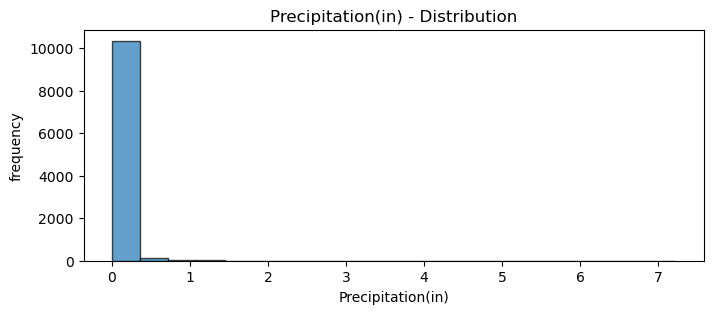

Precipitation(in): shows data distribution and spread


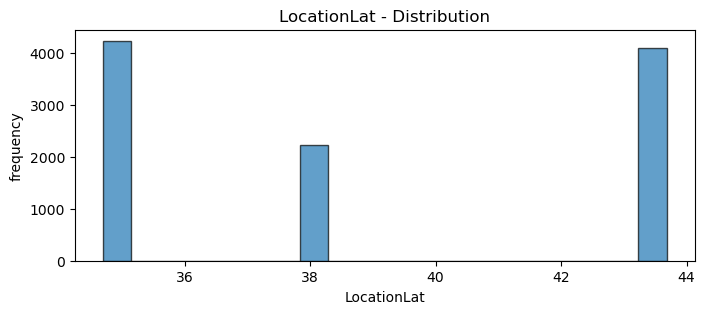

LocationLat: shows data distribution and spread


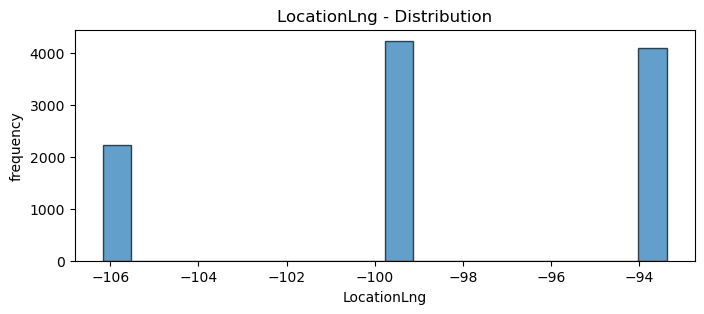

LocationLng: shows data distribution and spread


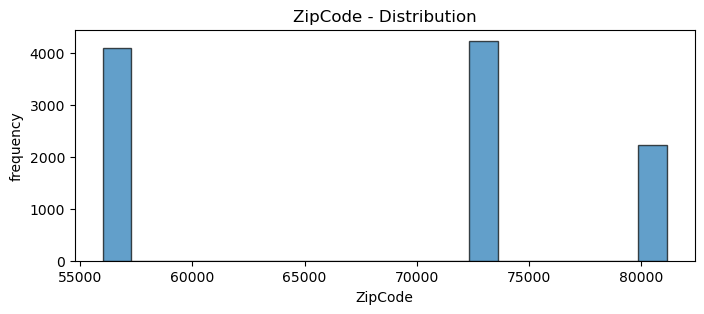

ZipCode: shows data distribution and spread


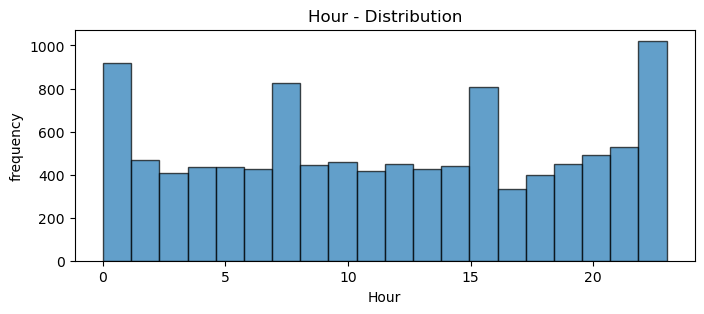

Hour: shows data distribution and spread


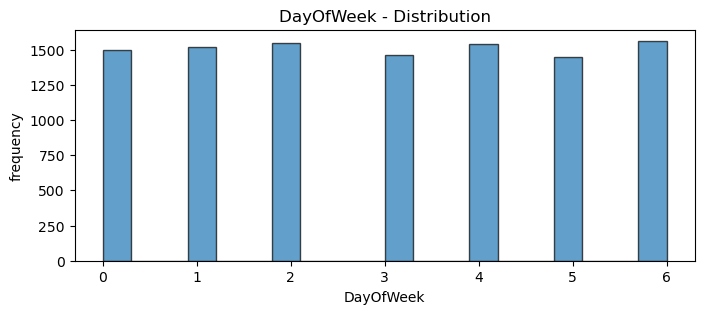

DayOfWeek: shows data distribution and spread


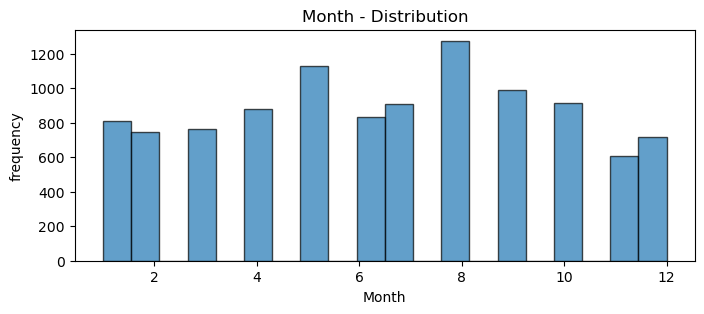

Month: shows data distribution and spread


In [7]:
numerical_columns = df_filled.select_dtypes(include=['number']).columns

for cols in numerical_columns:
    plt.figure(figsize=(8,3))
    plt.hist(df_filled[cols].dropna(), bins=20 , alpha = 0.7 , edgecolor = 'black')
    plt.title(f'{cols} - Distribution')
    plt.xlabel(cols)
    plt.ylabel('frequency')
    plt.show()
    print(f'{cols}: shows data distribution and spread' )


## TIme patterns here added 

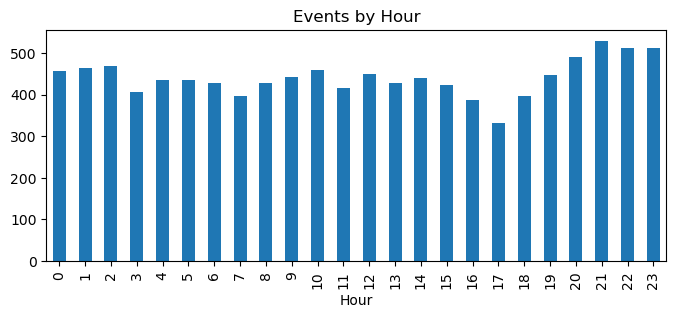

StartTime(UTC): Shows peak activity hours


In [8]:
# Date column - Time patterns
if 'StartTime(UTC)' in df_filled.columns:
    df_filled['Hour'] = pd.to_datetime(df_filled['StartTime(UTC)']).dt.hour
    plt.figure(figsize=(8, 3))
    df_filled['Hour'].value_counts().sort_index().plot(kind='bar')
    plt.title('Events by Hour')
    plt.show()
    print("StartTime(UTC): Shows peak activity hours")